# Causal Informed Machine Learning for Seasonal Prediction of Arctic Sea Ice

## Research question

Do winter atmospheric and oceanic conditions carry causal information about the following
summer's Arctic sea ice, beyond what secular trend and interannual persistence already provide?

The question separates into three parts. First, which winter variables stand in a genuine causal
relationship to the September minimum, as distinct from those that merely covary with it. Second,
whether restricting a statistical model to those variables improves forecast skill. Third, whether
any improvement is large enough to be distinguished from sampling noise given the length of the
satellite record.

## Approach

Predictors are constructed from ERA5 reanalysis over November to April. The target is Northern
Hemisphere sea ice from the NSIDC Sea Ice Index. Causal structure is estimated with PCMCI, a
conditional independence method designed for time series with lagged dependencies.

Two issues shape the design. Both predictors and target trend strongly over the satellite era, so
apparent dependencies may reflect shared response to external forcing rather than any seasonal
mechanism. Causal discovery is therefore run under three specifications, and only relationships
surviving all three are carried forward. Separately, the record provides roughly 45 annual samples,
which is few enough that differences in forecast skill require explicit uncertainty quantification
rather than point comparison.

## Contents

1. Setup
2. Data
3. Target
4. Predictors
5. Stationarity
6. Causal discovery
7. Benchmarks
8. Models
9. Significance
10. Prediction intervals
11. Attribution
12. Results
13. Limitations

## 1. Setup

All analytical choices are collected here so that any of them can be varied and the notebook rerun
without editing downstream cells.

In [31]:
import os
import numpy as np
import pandas as pd

WINTER_MONTHS = [11, 12, 1, 2, 3, 4]      # predictor season, November to April
TARGET_MONTHS = [9]                        # September minimum
TARGET_METRIC = "extent"                   # or "area"
YEARS = range(1979, 2026)
ARCTIC = [90, -180, 65, 180]               # north, west, south, east

TAU_MAX = 2                                # maximum lag, years
PC_ALPHA = 0.1                             # PCMCI condition selection
ALPHA = 0.05                               # reporting threshold

MIN_TRAIN = 15                             # first training window
N_BOOT = 5000
COVERAGE = 0.8                             # prediction interval level
SEED = 42

np.random.seed(SEED)

In [32]:
!pip install cdsapi tigramite shap netcdf4 h5netcdf -q

## 2. Data

### 2.1 Sea ice observations

The NSIDC Sea Ice Index (G02135) provides monthly sea ice extent and area for both hemispheres
from November 1978 onward, derived from passive microwave imagery using the NASA Team algorithm.
Analysis workbooks are distributed under the `seaice_analysis` directory. The `north/monthly/data`
directory holds per month CSV files rather than the workbooks.

NSIDC has reduced Sea Ice Today services following non renewal of funding, and the Sea Ice Index
has been placed at a Basic Level of Service. Paths and version numbers may therefore change. The
acquisition step tries several candidate locations, verifies that the response is a spreadsheet
rather than an error page, and falls back to any local copy.

In [33]:
import requests

ICE_URL = ("https://noaadata.apps.nsidc.org/NOAA/G02135/seaice_analysis/"
           "Sea_Ice_Index_Monthly_Data_by_Year_G02135_v4.0.xlsx")
ICE_FILE = ICE_URL.rsplit("/", 1)[-1]

if not os.path.exists(ICE_FILE):
    r = requests.get(ICE_URL, timeout=180)
    r.raise_for_status()
    assert r.content[:4] == b"PK\x03\x04", "not a spreadsheet, check the URL"
    open(ICE_FILE, "wb").write(r.content)

xl = pd.ExcelFile(ICE_FILE)
xl.sheet_names

['NH-Extent', 'NH-Area', 'SH-Extent', 'SH-Area', 'Documentation']

### 2.2 Atmospheric reanalysis

ERA5 monthly means are retrieved for the region north of 65 degrees. Eight fields are requested.

Five describe the surface state and circulation: two metre temperature, sea surface temperature,
the zonal and meridional wind components, and mean sea level pressure.

Three are added for their documented role in melt onset. Downwelling longwave radiation is a direct
control on the timing of melt and the clearest signature of moisture intrusion events. Net solar
radiation drives the ice albedo feedback once open water appears. Sea ice concentration provides a
partial measure of winter preconditioning.

Sea ice concentration is not a substitute for thickness. Thickness is the stronger precursor and is
discussed in section 13.

In [34]:
import cdsapi

KEY = os.environ.get("CDSAPI_KEY")
if KEY is None:                                  # running on Kaggle
    from kaggle_secrets import UserSecretsClient
    KEY = UserSecretsClient().get_secret("CDS_API_KEY")

rc = os.path.expanduser("~/.cdsapirc")
if not os.path.exists(rc):
    with open(rc, "w") as f:
        f.write(f"url: https://cds.climate.copernicus.eu/api\nkey: {KEY}\n")

cds = cdsapi.Client()

In [35]:
ERA5_FILE = "era5_arctic_winter.nc"

ERA5_VARS = [
    "2m_temperature",
    "sea_surface_temperature",
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "mean_sea_level_pressure",
    "mean_surface_downward_long_wave_radiation_flux",
    "surface_net_solar_radiation",
    "sea_ice_cover",
]

if not os.path.exists(ERA5_FILE):
    cds.retrieve("reanalysis-era5-single-levels-monthly-means", {
        "product_type": "monthly_averaged_reanalysis",
        "variable": ERA5_VARS,
        "year": [str(y) for y in YEARS],
        "month": [f"{m:02d}" for m in WINTER_MONTHS],
        "time": "00:00",
        "area": ARCTIC,
        "format": "netcdf",
    }, ERA5_FILE)

When a request mixes instantaneous fields with accumulated or averaged flux fields, the Climate
Data Store returns a zip archive carrying a `.nc` extension, containing one file per `stepType`.
The reader below identifies the format from the file signature before selecting a strategy.

The two component files are timestamped slightly differently. Merging on the union of timestamps
therefore doubles the record length and leaves half the rows empty. Timestamps are floored to the
month and the merge takes the intersection.

In [36]:
import zipfile
import xarray as xr

def read_era5(path, tmp="era5_unpacked"):
    if open(path, "rb").read(4) != b"PK\x03\x04":
        return xr.open_dataset(path)

    with zipfile.ZipFile(path) as z:
        z.extractall(tmp)

    parts = []
    for f in sorted(os.listdir(tmp)):
        if not f.endswith(".nc"):
            continue
        d = xr.open_dataset(os.path.join(tmp, f))
        d = d.assign_coords(valid_time=d.valid_time.values.astype("datetime64[M]"))
        parts.append(d)

    return xr.merge(parts, compat="override", join="inner")

ds = read_era5(ERA5_FILE)

# expver 0005 marks preliminary ERA5T months. The coordinate holds strings.
if "expver" in ds.coords and "0005" in set(np.atleast_1d(ds.expver.values).astype(str)):
    ds = ds.where(ds.expver.astype(str) == "0001", drop=True)
    print("preliminary ERA5T months dropped")

print(dict(ds.sizes))
print(sorted(ds.data_vars))
print(f"{len(YEARS) * len(WINTER_MONTHS)} timesteps expected")

{'valid_time': 282, 'latitude': 101, 'longitude': 1440}
['avg_sdlwrf', 'msl', 'siconc', 'ssr', 'sst', 't2m', 'u10', 'v10']
282 timesteps expected


In [37]:
# Sea surface temperature and ice concentration are ocean fields, so a missing
# fraction near 0.29 is the land mask over this domain.
ds[sorted(ds.data_vars)].isnull().mean().to_pandas().round(3)

avg_sdlwrf    0.000
msl           0.000
siconc        0.286
ssr           0.000
sst           0.286
t2m           0.000
u10           0.000
v10           0.000
dtype: float64

## 3. Target

Sea ice extent counts any grid cell above 15 percent concentration as fully covered. Sea ice area
weights each cell by its concentration. The two behave differently in summer, when surface melt
ponds are read by passive microwave sensors as open water and depress area more than extent.

Both are loaded. September is used as the primary target, being the annual minimum and the
conventional benchmark. The May to October mean is retained for sensitivity analysis.

In [38]:
MONTHS = ["January", "February", "March", "April", "May", "June",
          "July", "August", "September", "October", "November", "December"]
MONTH_NUM = {m: i + 1 for i, m in enumerate(MONTHS)}

def read_ice(quantity):
    sheet = next(s for s in xl.sheet_names
                 if quantity in s.lower() and ("nh" in s.lower() or "north" in s.lower()))
    d = pd.read_excel(ICE_FILE, sheet_name=sheet).rename(columns={"Unnamed: 0": "Year"})
    d = d[["Year"] + [m for m in MONTHS if m in d.columns]]
    d = d[d.Year.between(YEARS[0], YEARS[-1])]
    out = d.melt(id_vars="Year", var_name="Month", value_name="ice").dropna()
    out["mon"] = out.Month.map(MONTH_NUM)
    return out.sort_values(["Year", "mon"]).reset_index(drop=True)

extent, area = read_ice("extent"), read_ice("area")
print(f"{len(extent)} extent records, {len(area)} area records")

562 extent records, 561 area records


In [39]:
ice = area if TARGET_METRIC == "area" else extent

sept = ice[ice.mon.isin(TARGET_MONTHS)].groupby("Year").ice.mean()
mayoct = ice[ice.mon.between(5, 10)].groupby("Year").ice.mean()

targets = pd.DataFrame({"target": sept, "target_mayoct": mayoct}).reset_index()
print(f"September against May to October, r = {sept.corr(mayoct):.3f}")
targets.tail()

September against May to October, r = 0.981


,Year,target,target_mayoct
42,2021,4.952,8.096167
43,2022,4.897,8.257500
44,2023,4.381,8.053833
45,2024,4.351,7.812333
46,2025,4.747,7.836333


## 4. Predictors

### 4.1 Regional aggregation

Four regions are defined: the Barents and Kara Seas, the Beaufort Sea, the central Arctic, and the
Siberian shelf seas. Fields are reduced to regional means weighted by the cosine of latitude, which
corrects for the convergence of grid cells toward the pole.

Averaging is applied over ocean cells only where the field is masked over land. The weights are
renormalised across valid cells, so regional means of sea surface temperature and ice concentration
represent ocean conditions rather than being diluted by absent land values.

In [40]:
REGIONS = {
    "barents_kara":   (slice(82, 65), slice(20, 100)),
    "beaufort":       (slice(82, 65), slice(-160, -120)),
    "central_arctic": (slice(90, 80), slice(-180, 180)),
    "siberian":       (slice(82, 65), slice(100, 180)),
}

# The Climate Data Store renamed the averaged flux fields; both names are in circulation.
NAMES = {"t2m": "t2m", "sst": "sst", "u10": "u10", "v10": "v10", "msl": "msl",
         "avg_sdlwrf": "dlw", "msdwlwrf": "dlw", "ssr": "ssr", "siconc": "sic"}

weights = np.cos(np.deg2rad(ds.latitude))

def area_mean(var, lat, lon):
    box = ds[var].sel(latitude=lat, longitude=lon)
    return box.weighted(weights.sel(latitude=lat)).mean(["latitude", "longitude"]).values

cols = {}
for region, (lat, lon) in REGIONS.items():
    for raw, short in NAMES.items():
        if raw in ds.data_vars:
            cols[f"{region}_{short}"] = area_mean(raw, lat, lon)

X = pd.DataFrame(cols, index=ds.valid_time.values)
X.index.name = "date"
X.shape

(282, 32)

### 4.2 Dynamical indices

Regional means of the wind components are not informative. Averaging a zonal wind across an eighty
degree longitude band cancels opposing flows, leaving a mean near zero with most of the variance
removed. The relevant signal is destroyed by the aggregation rather than absent from the data.

Sea ice drift is approximately geostrophic, so pressure gradients rather than mean winds carry the
dynamical information. Three indices are constructed.

**Fram Strait export.** The pressure difference across the strait near 79 degrees north, between
the Greenland and Svalbard sides, sets the geostrophic drift that exports ice from the basin.

**Beaufort High.** Mean sea level pressure over the Beaufort Gyre. Anticyclonic conditions favour
convergence and retention of ice; cyclonic conditions favour divergence.

**Polar cap gradient.** The pressure difference between the region north of 80 degrees and the band
between 65 and 70 degrees. This is a proxy for the Arctic Oscillation, not the index itself, which
is defined as the leading empirical orthogonal function of sea level pressure north of 20 degrees
and cannot be computed from this domain.

Fields that are near constant are removed. Sea surface temperature under permanent ice carries no
variance, and net solar radiation is close to zero from November to April above 65 degrees, where
much of the season falls in polar night.

In [41]:
def slp(lat, lon):
    return area_mean("msl", lat, lon) / 100.0        # hPa

X["fram_export"] = slp(slice(81, 76), slice(-20, -5)) - slp(slice(81, 76), slice(5, 20))
X["beaufort_high"] = X.beaufort_msl / 100.0
X["polar_cap_gradient"] = (slp(slice(90, 80), slice(-180, 180))
                           - slp(slice(70, 65), slice(-180, 180)))

X = X.drop(columns=[c for c in X if c.endswith(("_u10", "_v10"))])

# All-NaN columns (permanently ice covered) fail the ratio test silently,
# so test for finiteness as well.
def uninformative(s):
    return not np.isfinite(s.std()) or s.std() / (s.abs().mean() + 1e-9) < 1e-4

flat = [c for c in X if c.endswith(("_sst", "_ssr")) and uninformative(X[c])]
if flat:
    print("dropped, no variance:", flat)
    X = X.drop(columns=flat)

print(f"{X.shape[1]} predictors")
sorted(X.columns)

dropped, no variance: ['beaufort_sst', 'central_arctic_sst', 'siberian_sst']
24 predictors


['barents_kara_dlw',
 'barents_kara_msl',
 'barents_kara_sic',
 'barents_kara_ssr',
 'barents_kara_sst',
 'barents_kara_t2m',
 'beaufort_dlw',
 'beaufort_high',
 'beaufort_msl',
 'beaufort_sic',
 'beaufort_ssr',
 'beaufort_t2m',
 'central_arctic_dlw',
 'central_arctic_msl',
 'central_arctic_sic',
 'central_arctic_ssr',
 'central_arctic_t2m',
 'fram_export',
 'polar_cap_gradient',
 'siberian_dlw',
 'siberian_msl',
 'siberian_sic',
 'siberian_ssr',
 'siberian_t2m']

### 4.3 Seasonal alignment

A winter season spans a calendar year boundary. November and December precede the melt season of
the following calendar year, whereas January to April fall within it. Both are assigned to that
following year, so each record pairs one complete winter with the September that follows it.

Seasons missing any of the six months are excluded rather than averaged over a partial window.

In [42]:
month = X.index.month
X["winter_year"] = np.where(np.isin(month, [11, 12]), X.index.year + 1, X.index.year)

counts = X.groupby("winter_year").size()
full = counts[counts == len(WINTER_MONTHS)].index

seasons = X[X.winter_year.isin(full)].groupby("winter_year").mean().reset_index()

data = seasons.merge(targets, left_on="winter_year", right_on="Year").drop(columns="Year")
data = data.sort_values("winter_year").reset_index(drop=True)
data["ice_lag1"] = data.target.shift(1)

print(f"{len(data)} complete seasons, {data.winter_year.min()} to {data.winter_year.max()}")
data[["winter_year", "target", "ice_lag1"]].tail()

46 complete seasons, 1980 to 2025


,winter_year,target,ice_lag1
41,2021,4.952,4.001
42,2022,4.897,4.952
43,2023,4.381,4.897
44,2024,4.351,4.381
45,2025,4.747,4.351


## 5. Stationarity

Every series in this analysis trends over the satellite era. Arctic temperature rises, sea ice
declines, and sea surface temperature rises. Partial correlation applied to trending series will
identify dependencies generated by that shared secular change rather than by any seasonal
mechanism.

PCMCI conditions on the other variables in the graph, but a common driver can only be conditioned
away if it is represented as a node. Two treatments are compared. The first removes the linear
trend from each series. The second introduces an explicit forcing variable, which retains the
information and makes the assumption visible in the estimated graph.

Augmented Dickey Fuller and KPSS tests are applied together because they take opposite null
hypotheses, and agreement between them is more informative than either alone.

In [43]:
from statsmodels.tsa.stattools import adfuller, kpss
import warnings; warnings.filterwarnings("ignore")

tested = [c for c in data if c not in ("winter_year", "ice_lag1", "target_mayoct")]

stat = pd.DataFrame({
    "adf_p": [adfuller(data[c].dropna(), autolag="AIC")[1] for c in tested],
    "kpss_p": [kpss(data[c].dropna(), regression="c", nlags="auto")[1] for c in tested],
}, index=tested).round(4)

stat["nonstationary"] = (stat.adf_p > 0.05) | (stat.kpss_p < 0.05)
print(f"{stat.nonstationary.sum()} of {len(stat)} nonstationary")
stat

17 of 25 nonstationary


,adf_p,kpss_p,nonstationary
barents_kara_t2m,0.8507,0.0100,True
barents_kara_sst,0.8156,0.0100,True
barents_kara_msl,0.0000,0.1000,False
barents_kara_dlw,0.1638,0.0100,True
barents_kara_ssr,0.5028,0.0100,True
barents_kara_sic,0.7518,0.0100,True
beaufort_t2m,0.8378,0.0100,True
beaufort_msl,0.0000,0.1000,False
beaufort_dlw,0.8494,0.0100,True
beaufort_ssr,0.0000,0.1000,False


In [44]:
# Forcing proxy. An observed global mean temperature series would be preferable;
# a smoothed Arctic mean is used here and is dominated by the forced trend.
t2m = [c for c in data if c.endswith("_t2m")]
data["forcing"] = data[t2m].mean(axis=1).rolling(11, center=True, min_periods=3).mean()

yr = data.winter_year.values.astype(float)

def detrend(s):
    return s - np.polyval(np.polyfit(yr, s, 1), yr)

detrended = data.copy()
for c in data:
    if c not in ("winter_year", "forcing", "target_mayoct"):
        detrended[c] = detrend(data[c].values.astype(float))

## 6. Causal discovery

PCMCI proceeds in two stages. A condition selection stage identifies candidate parents for each
variable; an momentary conditional independence stage then tests each candidate while conditioning
on the parents of both variables, which corrects the false positive rate under autocorrelation.

Three specifications are estimated: the raw series, the detrended series, and the raw series with
the forcing variable included as an additional node. A relationship present in the raw
specification but absent once forcing is conditioned on is attributable to shared trend rather than
to a seasonal mechanism. Only relationships appearing in all three are carried into the modelling
stage.

Two constraints on interpretation apply throughout. With roughly 45 annual observations and a
maximum lag of two years, statistical power is low, so the absence of a link is weak evidence for
the absence of a relationship. Contemporaneous edges are frequently returned unoriented, meaning
the method establishes dependence but not direction, and these are reported separately from
oriented links rather than described as parents.

Orientation carries an additional caveat specific to this design. Each row pairs one winter with
the September that follows it, so what the method labels lag zero is already the winter to summer
relationship. Where such an edge is returned unoriented, direction can still be argued from
temporal precedence, since winter precedes the following September and only one ordering is
physically available. That argument rests on the construction of the record rather than on the
algorithm, and should be stated as such.

In [45]:
from tigramite import data_processing as pp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr

CORE = [c for c in ["barents_kara_sst", "barents_kara_t2m", "siberian_t2m",
                    "central_arctic_msl", "fram_export", "beaufort_high",
                    "polar_cap_gradient", "target"] if c in data]

def discover(frame, extra=None):
    names = CORE + ([extra] if extra else [])
    sub = frame[names].dropna()
    pcmci = PCMCI(pp.DataFrame(sub.values, var_names=names),
                  cond_ind_test=ParCorr(significance="analytic"), verbosity=0)
    res = pcmci.run_pcmci(tau_max=TAU_MAX, pc_alpha=PC_ALPHA)
    graph = pcmci.get_graph_from_pmatrix(res["p_matrix"], ALPHA, 0, TAU_MAX)
    return {"res": res, "graph": graph, "names": names, "n": len(sub)}

runs = {
    "Raw series":        discover(data),
    "Detrended series":  discover(detrended),
    "With forcing node": discover(data, extra="forcing"),
}

for label, r in runs.items():
    print(f"{label:20s} n = {r['n']}")

Raw series           n = 46
Detrended series     n = 46
With forcing node    n = 46


In [46]:
EDGE = {"-->": "driver to ice", "<--": "reversed, ice to driver", "o-o": "unoriented"}

def links(run):
    graph, names, res = run["graph"], run["names"], run["res"]
    t = names.index("target")
    rows = [{"variable": v, "lag": lag,
             "direction": EDGE.get(graph[j, t, lag], graph[j, t, lag]),
             "effect": round(res["val_matrix"][j, t, lag], 3),
             "p": round(res["p_matrix"][j, t, lag], 5)}
            for j, v in enumerate(names) if v != "target"
            for lag in range(TAU_MAX + 1) if graph[j, t, lag]]
    return pd.DataFrame(rows)

for label, r in runs.items():
    print(f"\n{label}  (n = {r['n']})")
    tbl = links(r)
    print(tbl.to_string(index=False) if len(tbl) else "  no links to target")


Raw series  (n = 46)
          variable  lag  direction  effect       p
  barents_kara_t2m    0 unoriented  -0.509 0.00094
central_arctic_msl    0 unoriented   0.347 0.02838
     beaufort_high    0 unoriented   0.385 0.01406

Detrended series  (n = 46)
        variable  lag  direction  effect       p
barents_kara_t2m    0 unoriented  -0.482 0.00143
   beaufort_high    0 unoriented   0.352 0.02414

With forcing node  (n = 46)
        variable  lag  direction  effect       p
barents_kara_sst    0 unoriented  -0.328 0.04449
barents_kara_t2m    0 unoriented  -0.403 0.00898
   beaufort_high    0 unoriented   0.399 0.00976
         forcing    0 unoriented  -0.603 0.00005


In [47]:
def edges(run):
    t = links(run)
    return set(zip(t.variable, t.lag)) if len(t) else set()

survives = (edges(runs["Raw series"]) & edges(runs["Detrended series"])
            & edges(runs["With forcing node"]))
lost = edges(runs["Raw series"]) - edges(runs["With forcing node"])

print("under all three specifications:", sorted(survives) or "none")
print("eliminated by conditioning on forcing:", sorted(lost) or "none")

DRIVERS = sorted({v for v, _ in survives})
DRIVERS

under all three specifications: [('barents_kara_t2m', 0), ('beaufort_high', 0)]
eliminated by conditioning on forcing: [('central_arctic_msl', 0)]


['barents_kara_t2m', 'beaufort_high']

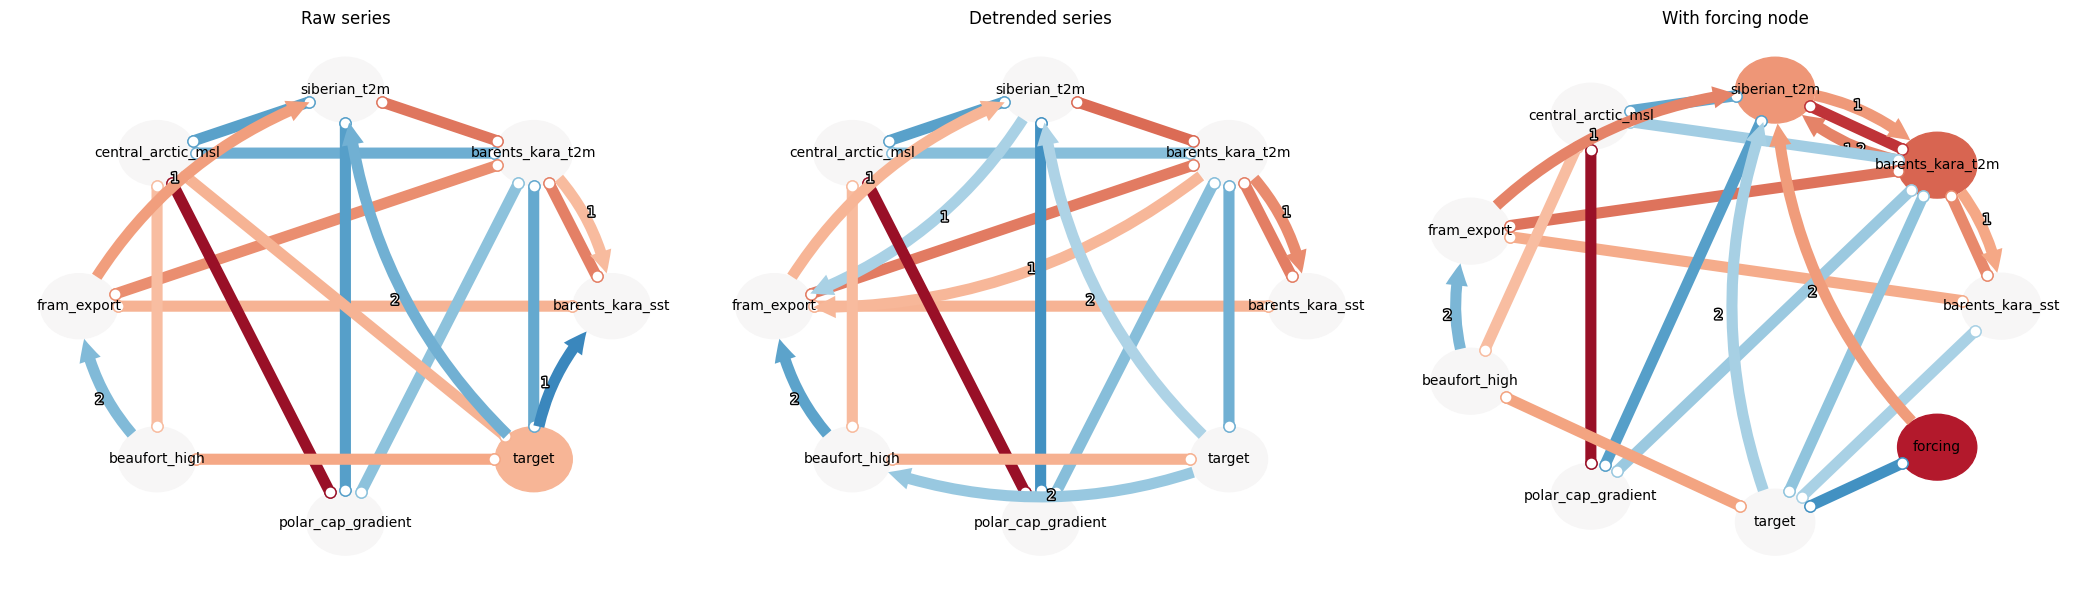

In [48]:
import matplotlib.pyplot as plt
from tigramite import plotting as tp

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, (label, r) in zip(axes, runs.items()):
    tp.plot_graph(val_matrix=r["res"]["val_matrix"], graph=r["graph"],
                  var_names=r["names"], fig_ax=(fig, ax), show_colorbar=False)
    ax.set_title(label)
plt.tight_layout()
plt.savefig("causal_graphs.png", dpi=150, bbox_inches="tight")

### 6.1 Comparison of dependence measures

Three measures are applied to the same variables. Pearson correlation quantifies marginal
association. Granger causality tests whether past values of one series improve prediction of
another beyond its own history, but cannot distinguish a driver from a variable sharing an
unobserved common cause. PCMCI conditions on the remaining variables and returns edge orientation
where the data support it.

The Granger tests are applied to the detrended series. Applied to trending series, their p values
are inflated by the shared secular component and cannot be interpreted at face value.

In [49]:
import contextlib, io
from statsmodels.tsa.stattools import grangercausalitytests

found = links(runs["With forcing node"])

def granger_p(pair):
    with contextlib.redirect_stdout(io.StringIO()):     # suppresses the fitted summaries
        g = grangercausalitytests(pair, maxlag=TAU_MAX)
    return min(g[l][0]["ssr_ftest"][1] for l in range(1, TAU_MAX + 1))

rows = []
for v in [c for c in CORE if c != "target"]:
    hit = found[found.variable == v]
    rows.append({
        "variable": v,
        "correlation": round(detrended.target.corr(detrended[v]), 3),
        "granger_p": round(granger_p(detrended[["target", v]].dropna()), 4),
        "pcmci": "; ".join(f"lag {r.lag} {r.direction}" for r in hit.itertuples()) or "none",
    })

pd.DataFrame(rows).sort_values("correlation", key=abs, ascending=False)

,variable,correlation,granger_p,pcmci
1,barents_kara_t2m,-0.482,0.9155,lag 0 unoriented
2,siberian_t2m,-0.309,0.1226,none
0,barents_kara_sst,-0.302,0.4395,lag 0 unoriented
3,central_arctic_msl,0.288,0.4388,none
5,beaufort_high,0.266,0.2109,lag 0 unoriented
6,polar_cap_gradient,0.247,0.5439,none
4,fram_export,-0.185,0.1306,none


## 7. Benchmarks

Skill is assessed against three reference forecasts. Climatology predicts the mean of all prior
observations. Persistence predicts the previous year's value. A linear trend forecast extrapolates
the fitted trend, and for a strongly trending target this is generally the strongest of the three.

Every forecast is generated under expanding window cross validation. For each test year, the model
sees only observations preceding it, and the training window grows forward through the record. A
model that does not exceed the best of these references has not demonstrated predictive value.

In [50]:
frame = data.dropna(subset=["ice_lag1"]).reset_index(drop=True)
y = frame.target.values
t = frame.winter_year.values.astype(float)
truth = y[MIN_TRAIN:]

def backtest(predict):
    return np.array([predict(i) for i in range(MIN_TRAIN, len(y))])

def score(pred):
    e = truth - pred
    return {"RMSE": np.sqrt((e ** 2).mean()),
            "MAE": np.abs(e).mean(),
            "R2": 1 - (e ** 2).sum() / ((truth - truth.mean()) ** 2).sum(),
            "err2": e ** 2}

REFS = {
    "climatology": lambda i: y[:i].mean(),
    "persistence": lambda i: y[i - 1],
    "trend": lambda i: np.polyval(np.polyfit(t[:i], y[:i], 1), t[i]),
    "trend and persistence": lambda i: 0.5 * np.polyval(np.polyfit(t[:i], y[:i], 1), t[i])
                                       + 0.5 * y[i - 1],
}

refs = {k: score(backtest(f)) for k, f in REFS.items()}
ref_table = pd.DataFrame(refs).T[["RMSE", "MAE", "R2"]].astype(float).round(3)

BEST_REF = ref_table.RMSE.idxmin()
print(f"reference for comparison: {BEST_REF}\n")
ref_table

reference for comparison: trend and persistence



,RMSE,MAE,R2
climatology,1.369,1.235,-1.196
persistence,0.680,0.515,0.458
trend,0.607,0.467,0.568
trend and persistence,0.592,0.448,0.589


## 8. Models

Four estimators are applied across three predictor sets. The predictor sets are the variables
surviving causal discovery, those variables together with the previous year's ice, and all
available predictors with the previous year's ice.

All preprocessing is contained within a pipeline so that scaling is refitted on each training
window and never sees the test observation. For the neural network the target is scaled as well as
the predictors, and early stopping is disabled. With training windows of fifteen observations, an
internal validation split would leave three observations and terminate optimisation almost
immediately, producing a model that has not converged.

Each configuration is fitted two ways. The first regresses on the target directly. The second
regresses on the residual from a linear trend fitted to the training window alone, then adds the
trend back at prediction time. The distinction matters because tree ensembles cannot predict
outside the range of values seen in training, so on a declining series they are biased high and
are penalised for an inability to extrapolate rather than for the quality of their predictors.
Reporting both framings separates the two effects.

The range of each model's predictions is reported alongside its skill. Sea ice extent cannot be
negative, so a model producing negative values has failed to train and its skill is not
interpretable.

In [51]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor

def scaled(estimator):
    return make_pipeline(StandardScaler(), estimator)

MODELS = {
    "Linear": lambda: scaled(LinearRegression()),
    "Ridge": lambda: scaled(Ridge(alpha=1.0)),
    "RandomForest": lambda: scaled(RandomForestRegressor(n_estimators=300, max_depth=4,
                                                         random_state=SEED)),
    "NeuralNet": lambda: TransformedTargetRegressor(
        regressor=scaled(MLPRegressor(hidden_layer_sizes=(8,), activation="tanh",
                                      alpha=0.1, early_stopping=False,
                                      max_iter=5000, random_state=SEED)),
        transformer=StandardScaler()),
}

def fit_predict(build, X, anomaly=True):
    def step(i):
        m = build()
        if not anomaly:
            m.fit(X.iloc[:i], y[:i])
            return m.predict(X.iloc[[i]])[0]
        line = np.polyfit(t[:i], y[:i], 1)                 # fitted on training years only
        m.fit(X.iloc[:i], y[:i] - np.polyval(line, t[:i]))
        return m.predict(X.iloc[[i]])[0] + np.polyval(line, t[i])
    return backtest(step)

In [52]:
PREDICTORS = {
    "causal": [d for d in DRIVERS if d in frame],
    "causal with persistence": [d for d in DRIVERS if d in frame] + ["ice_lag1"],
    "all with persistence": [c for c in frame
                             if c not in ("winter_year", "target", "target_mayoct", "forcing")],
}
PREDICTORS = {k: v for k, v in PREDICTORS.items() if v}

for k, v in PREDICTORS.items():
    print(f"{k}: {len(v)}")

causal: 2
causal with persistence: 3
all with persistence: 25


In [53]:
fits, rows = {}, []
for pname, cols in PREDICTORS.items():
    for mname, build in MODELS.items():
        if mname == "Linear" and len(cols) > 6:
            continue                       # underdetermined at this sample size
        for anomaly in (False, True):
            pred = fit_predict(build, frame[cols], anomaly)
            s = score(pred)
            fits[(pname, mname, anomaly)] = (pred, s)
            rows.append({"predictors": pname, "n": len(cols), "model": mname,
                         "anomaly": anomaly, "RMSE": s["RMSE"], "MAE": s["MAE"],
                         "R2": s["R2"], "range": f"{pred.min():.2f} to {pred.max():.2f}"})

skill = pd.DataFrame(rows).sort_values("RMSE").round(3)
top = skill.iloc[0]
BEST = (top.predictors, top.model, bool(top.anomaly))
print(f"{BEST_REF} reference, RMSE {refs[BEST_REF]['RMSE']:.3f}\n")
skill.head(12)

trend and persistence reference, RMSE 0.592



,predictors,n,model,anomaly,RMSE,MAE,R2,range
3,causal,2,Ridge,True,0.574,0.475,0.614,3.74 to 6.98
1,causal,2,Linear,True,0.574,0.477,0.613,3.74 to 6.99
7,causal,2,NeuralNet,True,0.578,0.477,0.609,3.72 to 7.07
11,causal with persistence,3,Ridge,True,0.579,0.470,0.607,3.87 to 6.84
9,causal with persistence,3,Linear,True,0.579,0.470,0.606,3.85 to 6.85
5,causal,2,RandomForest,True,0.585,0.498,0.598,3.50 to 7.18
13,causal with persistence,3,RandomForest,True,0.613,0.520,0.560,3.51 to 6.86
8,causal with persistence,3,Linear,False,0.614,0.515,0.558,3.79 to 7.25
10,causal with persistence,3,Ridge,False,0.617,0.521,0.553,3.85 to 7.23
15,causal with persistence,3,NeuralNet,True,0.620,0.505,0.549,3.36 to 7.16


## 9. Significance

The test set contains roughly thirty observations. At that size, differences in root mean squared
error of a few hundredths lie within sampling variation, and ranking models by point estimate alone
would overstate what the record can support.

A paired bootstrap resamples the fold level squared errors of two forecasts jointly, preserving the
pairing across resamples, and returns a confidence interval for the difference. Intervals spanning
zero indicate forecasts that cannot be distinguished at this sample size.

In [56]:
rng = np.random.default_rng(SEED)

def compare(a, b, n_boot=N_BOOT):
    idx = rng.integers(0, len(a), (n_boot, len(a)))
    d = np.sqrt(a[idx].mean(1)) - np.sqrt(b[idx].mean(1))
    lo, hi = np.percentile(d, [2.5, 97.5])
    return {"delta_RMSE": np.sqrt(a.mean()) - np.sqrt(b.mean()),
            "lo": lo, "hi": hi,
            "p": 2 * min((d > 0).mean(), (d < 0).mean()),
            "distinguishable": lo > 0 or hi < 0}

base = refs[BEST_REF]["err2"]
print(f"Against the {BEST_REF} reference. Negative delta means lower error.\n")

pd.DataFrame([{"model": f"{p} / {m}", "anomaly": a, **compare(s["err2"], base)}
              for (p, m, a), (_, s) in fits.items()]).sort_values("delta_RMSE").round(4)

Against the trend and persistence reference. Negative delta means lower error.



,model,anomaly,delta_RMSE,lo,hi,p,distinguishable
3,causal / Ridge,True,-0.0185,-0.1287,0.1095,0.7696,False
1,causal / Linear,True,-0.0179,-0.1332,0.1115,0.7824,False
7,causal / NeuralNet,True,-0.0144,-0.1275,0.1195,0.8268,False
11,causal with persistence / Ridge,True,-0.0130,-0.1350,0.1259,0.8676,False
9,causal with persistence / Linear,True,-0.0127,-0.1347,0.1200,0.8732,False
5,causal / RandomForest,True,-0.0068,-0.1332,0.1454,0.9244,False
13,causal with persistence / RandomForest,True,0.0206,-0.1093,0.1791,0.7372,False
8,causal with persistence / Linear,False,0.0218,-0.1365,0.1682,0.7580,False
10,causal with persistence / Ridge,False,0.0251,-0.1305,0.1693,0.7184,False
15,causal with persistence / NeuralNet,True,0.0281,-0.1216,0.2021,0.7072,False


In [57]:
# Restricting predictors to the causal set, estimator and framing held fixed.
for mname in MODELS:
    a = fits.get(("all with persistence", mname, True))
    b = fits.get(("causal with persistence", mname, True))
    if a and b:
        r = compare(a[1]["err2"], b[1]["err2"])
        print(f"{mname:13s} delta {r['delta_RMSE']:+.3f}  "
              f"CI [{r['lo']:+.3f}, {r['hi']:+.3f}]  p {r['p']:.3f}")

Ridge         delta +0.189  CI [+0.019, +0.345]  p 0.030
RandomForest  delta +0.047  CI [-0.046, +0.133]  p 0.336
NeuralNet     delta +0.161  CI [-0.002, +0.307]  p 0.054


## 10. Prediction intervals

Point forecasts understate what is known about a quantity dominated by internal variability. Two
interval methods are applied.

Split conformal prediction constructs intervals from the empirical distribution of past absolute
residuals. It is distribution free and provides finite sample coverage under exchangeability. That
assumption is strained by a trending series, so empirical coverage is measured against the nominal
level rather than assumed to hold.

Quantile regression estimates conditional quantiles directly and permits asymmetric intervals,
which is appropriate where forecast uncertainty is not symmetric about the median. It is applied
to trend residuals for the reason given in section 8, and uses a linear quantile estimator, which
extrapolates where a tree ensemble cannot.

Empirical coverage of the quantile intervals should be expected to fall below nominal. Estimating
a tenth and ninetieth percentile from training windows of fifteen to forty observations is
imprecise, and no choice of estimator removes that limit. Coverage is reported rather than
assumed, and the conformal intervals are the more reliable of the two at this sample size.

In [58]:
pred_best = fits[BEST][0]
resid = np.abs(truth - pred_best)

WARMUP = 8
q = np.array([np.quantile(resid[:i], COVERAGE) if i >= WARMUP else np.nan
              for i in range(len(resid))])
lo, hi = pred_best - q, pred_best + q

covered = ((truth >= lo) & (truth <= hi))[WARMUP:].mean()
print(f"conformal, nominal {COVERAGE:.0%}, empirical {covered:.0%}")
if abs(covered - COVERAGE) > 0.1:
    print("coverage departs from nominal; exchangeability is strained by the trend")

conformal, nominal 80%, empirical 59%
coverage departs from nominal; exchangeability is strained by the trend


In [59]:
from sklearn.linear_model import QuantileRegressor

qcols = PREDICTORS.get("causal with persistence", list(PREDICTORS.values())[0])
Xq = frame[qcols]

def quantile_at(tau):
    def step(i):
        line = np.polyfit(t[:i], y[:i], 1)
        m = scaled(QuantileRegressor(quantile=tau, alpha=0.01, solver="highs"))
        m.fit(Xq.iloc[:i], y[:i] - np.polyval(line, t[:i]))
        return m.predict(Xq.iloc[[i]])[0] + np.polyval(line, t[i])
    return backtest(step)

q10, q50, q90 = (quantile_at(tau) for tau in (0.1, 0.5, 0.9))
print(f"quantile interval, nominal 80%, empirical "
      f"{((truth >= q10) & (truth <= q90)).mean():.0%}")
print(f"median bias {np.mean(q50 - truth):+.3f}")

quantile interval, nominal 80%, empirical 63%
median bias -0.014


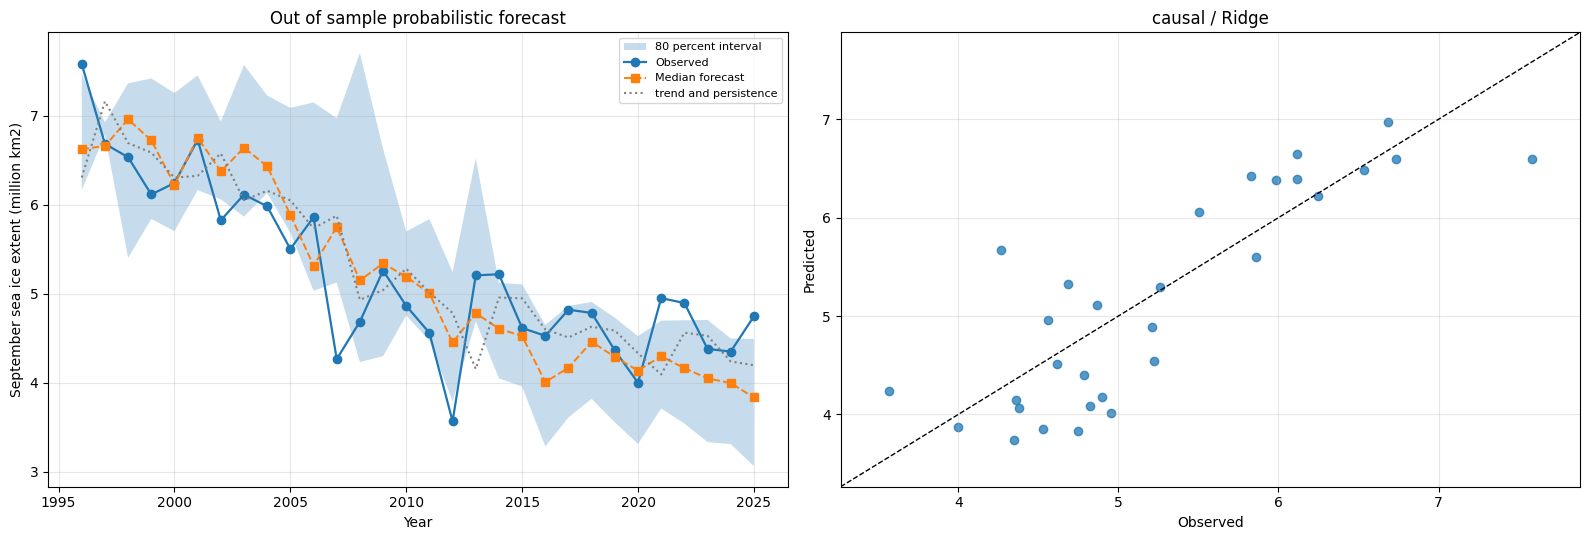

In [60]:
years = t[MIN_TRAIN:]
ref_pred = backtest(REFS[BEST_REF])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

ax1.fill_between(years, q10, q90, alpha=0.25, label="80 percent interval")
ax1.plot(years, truth, "o-", label="Observed", lw=1.6)
ax1.plot(years, q50, "s--", label="Median forecast", lw=1.4)
ax1.plot(years, ref_pred, ":", color="grey", label=BEST_REF)
ax1.set(xlabel="Year", ylabel=f"September sea ice {TARGET_METRIC} (million km2)",
        title="Out of sample probabilistic forecast")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

ax2.scatter(truth, pred_best, alpha=0.75)
lims = [min(truth.min(), pred_best.min()) - 0.3, max(truth.max(), pred_best.max()) + 0.3]
ax2.plot(lims, lims, "k--", lw=1)
ax2.set(xlim=lims, ylim=lims, xlabel="Observed", ylabel="Predicted",
        title=f"{BEST[0]} / {BEST[1]}")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("forecast.png", dpi=150, bbox_inches="tight")

## 11. Attribution

Shapley values decompose each prediction into additive contributions from the input variables,
giving both a magnitude and a direction for each. The model is refitted on the complete record for
this purpose. Attribution describes the fitted relationship and is not an estimate of predictive
skill, which is reported in section 8.

Where the previous year's ice accounts for the majority of attributed importance, the model is
principally propagating persistence, and the winter variables contribute a secondary increment.

ice_lag1            69.9
barents_kara_t2m    20.3
beaufort_high        9.8
Name: share_pct, dtype: float64

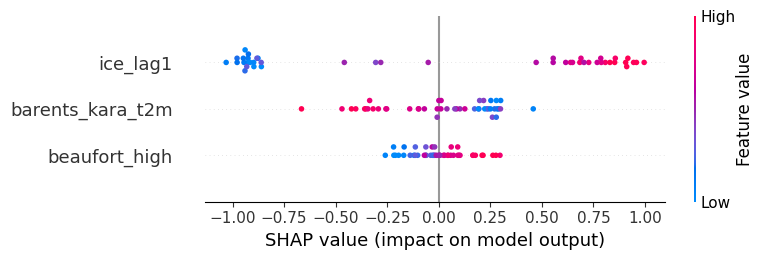

In [61]:
import shap

Xs = frame[qcols]
scaler = StandardScaler().fit(Xs)
rf = RandomForestRegressor(n_estimators=300, max_depth=4, random_state=SEED)
rf.fit(scaler.transform(Xs), y)

vals = shap.TreeExplainer(rf).shap_values(scaler.transform(Xs))
shap.summary_plot(vals, Xs, feature_names=qcols, show=False)
plt.tight_layout()
plt.savefig("shap.png", dpi=150, bbox_inches="tight")

importance = pd.Series(np.abs(vals).mean(0), index=qcols).sort_values(ascending=False)
(importance / importance.sum() * 100).round(1).rename("share_pct")

## 12. Results

In [62]:
best_skill = fits[BEST][1]
verdict = compare(best_skill["err2"], base)
gain = (1 - best_skill["RMSE"] / refs[BEST_REF]["RMSE"]) * 100
framing = "anomaly" if BEST[2] else "raw target"

print(f"Target             September sea ice {TARGET_METRIC}")
print(f"Seasons            {len(frame)}")
print(f"Test observations  {len(truth)}, expanding window")
print()
print(f"Reference          {BEST_REF}, RMSE {refs[BEST_REF]['RMSE']:.3f}")
print(f"Best model         {BEST[0]} / {BEST[1]} ({framing})")
print(f"                   RMSE {best_skill['RMSE']:.3f}, R2 {best_skill['R2']:.3f}")
print(f"Gain               {gain:+.1f} percent")
print(f"95 percent CI      [{verdict['lo']:+.3f}, {verdict['hi']:+.3f}], "
      f"p = {verdict['p']:.3f}")
print()
if verdict["distinguishable"] and verdict["delta_RMSE"] < 0:
    print("The model improves on the reference by a margin distinguishable from zero.")
elif verdict["distinguishable"]:
    print("The model is worse than the reference by a margin distinguishable from zero.")
else:
    print(f"The difference from the reference is not distinguishable from zero")
    print(f"with {len(truth)} test observations.")
print()
print(f"Surviving all three specifications:    {DRIVERS or 'none'}")
print(f"Eliminated by conditioning on forcing: {sorted({v for v, _ in lost}) or 'none'}")

Target             September sea ice extent
Seasons            45
Test observations  30, expanding window

Reference          trend and persistence, RMSE 0.592
Best model         causal / Ridge (anomaly)
                   RMSE 0.574, R2 0.614
Gain               +3.1 percent
95 percent CI      [-0.126, +0.105], p = 0.788

The difference from the reference is not distinguishable from zero
with 30 test observations.

Surviving all three specifications:    ['barents_kara_t2m', 'beaufort_high']
Eliminated by conditioning on forcing: ['central_arctic_msl']


## 13. Limitations and further work

**Sample size.** Roughly 45 annual observations constrain every stage of the analysis. Conditional
independence testing has low power at this size, confidence intervals on skill differences are
wide, and the distinction between competing models is often not resolvable. Climate model
ensembles provide the standard route to larger samples, at the cost of a transfer problem between
simulated and observed conditions.

**Sea ice thickness.** Spring thickness and volume are the strongest documented precursors of the
September minimum and are not represented here. ERA5 sea ice concentration is a partial substitute.
Incorporating PIOMAS or CryoSat 2 thickness is the single change most likely to improve skill.

**Forcing proxy.** The smoothed Arctic mean temperature used as a forcing variable is derived from
the same fields it is intended to condition. An observational global mean temperature series or a
radiative forcing series would be independent of the predictors and preferable.

**Circulation indices.** The polar cap pressure gradient is a proxy for the Arctic Oscillation
rather than the index itself, which requires hemispheric coverage south of the retrieved domain.
The Arctic Dipole, which exerts strong control on ice export, is likewise not represented.

**Temporal resolution.** Averaging November to April into a single value discards the timing of
moisture intrusion events, which is where much of the physical mechanism resides. Monthly
predictors with explicit lags would allow the lag structure of the causal method to be used rather
than collapsing to contemporaneous relationships.

**Latent confounders.** PCMCI assumes causal sufficiency, that all common causes are observed.
LPCMCI relaxes this assumption and would provide a check on the robustness of the estimated graph.

**Spring predictability barrier.** Forecasts initialised before May lose skill sharply, because the
September minimum depends substantially on weather that has not yet occurred. This places an upper
bound on achievable skill at the lead time examined here, independent of method.